# JAX-Compatible Quantum Rotation Optimization

This notebook demonstrates gradient-based optimization of quantum rotation gates using JAX automatic differentiation and QuTiP quantum simulations. We optimize two Ry rotation angles to maximize the probability of measuring the qubit in the excited state.

## System Overview

The simulation uses a **three-system composite Hilbert space**:
1. **Input cavity**: Placeholder for future input field coupling (unused in this example)
2. **Resonator cavity**: Main cavity mode coupled to the qubit 
3. **Qubit**: Two-level system that can be rotated and measured

### Optimization Workflow:
1. **Initialize**: Start with excited resonator cavity state |0,1,0⟩ 
2. **Rotate**: Apply first Ry(θ₁) rotation to qubit
3. **Evolve**: Time evolution under cavity-qubit coupling Hamiltonian
4. **Rotate**: Apply second Ry(θ₂) rotation to qubit  
5. **Measure**: Calculate probability of qubit in |1⟩ state
6. **Optimize**: Use JAX gradients to find optimal θ₁, θ₂

## Required Libraries

Import the essential libraries for JAX-compatible quantum optimization:
- **JAX**: Automatic differentiation and numerical computing
- **QuTiP**: Quantum state manipulation and time evolution  
- **NumPy & Matplotlib**: Numerical operations and visualization
- **Optax**: JAX-based optimization algorithms

In [ ]:
import jax
import qutip as qt
import qutip_jax  # Enables JAX backend for QuTiP
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax  # JAX optimization library

# Verify JAX-QuTiP compatibility
print("JAX version:", jax.__version__)
print("QuTiP version:", qt.__version__)


JAX version: 0.4.35
QuTiP version: 5.2.0
✓ JAX-QuTiP backend enabled


## System Parameters

Key parameters for the three-system composite Hilbert space:
- **nlev**: Hilbert space dimension for each cavity (input + resonator)
- **chi**: Dispersive coupling strength between resonator and qubit
- **gm**: Resonator cavity decay rate (not used in time-independent evolution)
- **Evolution time**: Duration for Hamiltonian time evolution between rotations

In [31]:
# System parameters for three-cavity composite space: input ⊗ resonator ⊗ qubit
nlev = 2         # Number of levels in each cavity (input and resonator)
chi = 0.1        # Dispersive coupling between resonator and qubit
evolution_time = 1.0  # Time evolution duration between rotations

print(f"Composite Hilbert space dimension: {nlev} × {nlev} × 2 = {nlev * nlev * 2}")
print(f"Dispersive coupling χ = {chi}")
print(f"Evolution time = {evolution_time}")

Composite Hilbert space dimension: 2 × 2 × 2 = 8
Dispersive coupling χ = 0.1
Evolution time = 1.0


## Quantum Operators for Three-System Composite Space

Create operators for the composite Hilbert space: **input cavity ⊗ resonator cavity ⊗ qubit**

### Individual System Operators:
- **Input cavity**: Annihilation/creation operators (currently unused)
- **Resonator cavity**: Annihilation/creation operators coupled to qubit
- **Qubit**: Pauli matrices and projection operators for rotations and measurements

### Composite Operators:
All operators are embedded in the full three-system tensor product space using QuTiP's `tensor()` function with JAX backend enabled.

In [30]:
# Quantum operators for three-cavity system: input_cavity ⊗ resonator_cavity ⊗ qubit
# Create JAX-backed operators for three-system composite space
with qt.CoreOptions(default_dtype="jax"):
    # ==================== INDIVIDUAL SYSTEM OPERATORS ====================
    # Basic operators for each subsystem
    I2 = qt.qeye(2)           # Qubit identity (2×2)
    In = qt.qeye(nlev)        # Cavity identity (nlev×nlev)
    An = qt.destroy(nlev)     # Cavity annihilation operator
    Acn = qt.create(nlev)     # Cavity creation operator

    # Qubit Pauli operators
    Sx = qt.sigmax()          # σx Pauli operator
    Sy = qt.sigmay()          # σy Pauli operator  
    Sz = qt.sigmaz()          # σz Pauli operator

    # Qubit projection operators
    P0 = qt.Qobj([[1, 0], [0, 0]])  # |0⟩⟨0| projection
    P1 = qt.Qobj([[0, 0], [0, 1]])  # |1⟩⟨1| projection

    # ==================== COMPOSITE SYSTEM OPERATORS ====================
    # System structure: input_cavity ⊗ resonator_cavity ⊗ qubit

    # Input cavity operators (unused in this example, but part of full space)
    ain = qt.tensor(An, In, I2)        # Input cavity annihilation
    ainc = ain.dag()                   # Input cavity creation

    # Resonator cavity operators (main cavity coupled to qubit)
    a_res = qt.tensor(In, An, I2)      # Resonator cavity annihilation
    ac_res = a_res.dag()               # Resonator cavity creation

    # Qubit operators in composite space
    sx_qubit = qt.tensor(In, In, Sx)   # σx for qubit
    sy_qubit = qt.tensor(In, In, Sy)   # σy for qubit  
    sz_qubit = qt.tensor(In, In, Sz)   # σz for qubit

    # Qubit measurement projectors in composite space
    proj_0 = qt.tensor(In, In, P0)     # Project qubit onto |0⟩
    proj_1 = qt.tensor(In, In, P1)     # Project qubit onto |1⟩

print(f"✓ All operators use JAX backend: {type(a_res.data)}")
print("Operators ready for gradient-based optimization")

✓ All operators use JAX backend: <class 'qutip_jax.jaxarray.JaxArray'>
Operators ready for gradient-based optimization


## JAX-Compatible Quantum Functions

Define JAX-differentiable functions for quantum operations:
- **Measurement**: Calculate qubit state probabilities from density matrices
- **Rotation**: Apply Ry rotations to qubit in the composite space

These functions use direct matrix operations on JAX arrays to ensure gradient compatibility.

In [33]:
def measure_qubit(rho, state):
    """
    JAX-compatible measurement of qubit state probability.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        state: int, 0 for |0⟩ state, 1 for |1⟩ state
        
    Returns:
        JAX array: Probability of measuring qubit in specified state
    """
    proj_op = proj_0 if state == 0 else proj_1
    rho_data = rho.data._jxa
    proj_data = proj_op.data._jxa
    temp = jnp.matmul(proj_data, rho_data)
    result = jnp.matmul(temp, jnp.conj(proj_data).T)
    return jnp.real(jnp.trace(result))

def apply_qubit_rotation(rho, theta):
    """
    Apply Ry rotation to qubit in the three-system composite space.
    
    Args:
        rho: QuTiP Qobj density matrix
        theta: float or JAX array, Ry rotation angle
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    with qt.CoreOptions(default_dtype="jax"):
        # Create Ry rotation gate for single qubit
        ry_gate = (-1j * Sy * theta / 2).expm()
        # Embed in composite space: input ⊗ resonator ⊗ qubit
        ry_composite = qt.tensor(In, In, ry_gate)
    
    return ry_composite * rho * ry_composite.dag()

print("JAX-compatible quantum functions defined")

JAX-compatible quantum functions defined


## System Hamiltonian

Define a simple time-independent Hamiltonian for the resonator-qubit subsystem:
- **Resonator term**: Energy of photons in the resonator cavity
- **Qubit term**: Energy splitting of the two-level system
- **Interaction term**: Dispersive coupling between resonator photons and qubit

The input cavity is not coupled in this example, making the Hamiltonian block-diagonal in the input cavity subspace.

In [35]:
def meas(rho, state):
    """JAX-compatible measurement probability calculation.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        state: int, 0 for |0⟩ state, 1 for |1⟩ state
        
    Returns:
        JAX array: Probability of measuring qubit in specified state
    """
    proj_op = p0 if state == 0 else p1
    rho_data = rho.data._jxa
    proj_data = proj_op.data._jxa
    temp = jnp.matmul(proj_data, rho_data)
    result = jnp.matmul(temp, jnp.conj(proj_data).T)
    return jnp.real(jnp.trace(result))

def apply_ry_rotation(rho, theta):
    """
    Apply Ry rotation to the qubit in the composite system.
    
    Args:
        rho: QuTiP Qobj density matrix
        theta: float or JAX array, rotation angle
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    with qt.CoreOptions(default_dtype="jax"):
        # Create Ry rotation gate
        ry_gate = (-1j * Sy * theta / 2).expm()
        # Embed in composite space: input ⊗ output ⊗ qubit
        rotation_op = qt.tensor(In, In, ry_gate)
    
    return rotation_op * rho * rotation_op.dag()

print("JAX-compatible measurement and rotation functions defined!")



JAX-compatible measurement and rotation functions defined!


In [36]:
# Define time-independent Hamiltonian for resonator-qubit interaction
with qt.CoreOptions(default_dtype="jax"):
    # Hamiltonian components (input cavity decoupled)
    H_resonator = ac_res * a_res                      # Resonator photon energy
    H_qubit = 0.5 * sz_qubit                          # Qubit energy splitting  
    H_interaction = chi * ac_res * a_res * sz_qubit   # Dispersive coupling
    
    # Total system Hamiltonian
    H_total = H_resonator + H_qubit + H_interaction

# Create solver for time evolution with JAX compatibility
solver = qt.MESolver(H_total, [], options={"method": "diffrax", "normalize_output": False})

print("Time-independent Hamiltonian created")
print(f"Hamiltonian shape: {H_total.shape}")
print("JAX-compatible solver initialized")

Time-independent Hamiltonian created
Hamiltonian shape: (8, 8)
JAX-compatible solver initialized


## Optimization Objective Function

Implement the complete quantum workflow as a JAX-differentiable function:

### Workflow Steps:
1. **Initial State**: |0,1,0⟩ (input=vacuum, resonator=1 photon, qubit=ground)
2. **First Rotation**: Apply Ry(θ₁) to qubit
3. **Evolution**: Time evolution under resonator-qubit coupling  
4. **Second Rotation**: Apply Ry(θ₂) to qubit
5. **Measurement**: Probability of qubit in excited state |1⟩

The objective is to maximize P(qubit=|1⟩) by optimizing rotation angles θ₁ and θ₂.

In [37]:
# Create the solver for time evolution
solver = qt.MESolver(H_total, [], options={"method": "diffrax", "normalize_output": False})

def optimization_objective(theta1, theta2):
    """
    Complete quantum workflow: Initial state → Ry(θ₁) → Evolution → Ry(θ₂) → Measurement
    
    Args:
        theta1: First Ry rotation angle
        theta2: Second Ry rotation angle
        
    Returns:
        Probability of measuring qubit in |1⟩ state
    """
    # Step 1: Create initial state |0,1,0⟩ (input=0, resonator=1, qubit=0)
    with qt.CoreOptions(default_dtype="jax"):
        psi_initial = qt.tensor(qt.basis(nlev, 0), qt.basis(nlev, 1), qt.basis(2, 0))
        rho_initial = psi_initial * psi_initial.dag()
    
    # Step 2: Apply first Ry rotation to qubit
    rho_after_rot1 = apply_qubit_rotation(rho_initial, theta1)
    
    # Step 3: Time evolution under resonator-qubit coupling
    result = solver.run(rho_after_rot1, [0, evolution_time])
    rho_evolved = result.states[-1]
    
    # Step 4: Apply second Ry rotation to qubit
    rho_after_rot2 = apply_qubit_rotation(rho_evolved, theta2)
    
    # Step 5: Measure probability of qubit in excited state |1⟩
    prob_excited = measure_qubit(rho_after_rot2, 1)
    
    return prob_excited

# Test the objective function and gradients
print("Testing optimization objective...")
test_theta1, test_theta2 = jnp.pi/4, jnp.pi/6
test_prob = optimization_objective(test_theta1, test_theta2)
print(f"Test probability P(|1⟩) = {test_prob:.6f}")

# Verify JAX gradient computation
grad_fn = jax.grad(optimization_objective, argnums=(0, 1))
grads = grad_fn(test_theta1, test_theta2)
print(f"Gradients: ∂P/∂θ₁ = {grads[0]:.6f}, ∂P/∂θ₂ = {grads[1]:.6f}")
print("JAX-compatible optimization workflow ready!")



Testing optimization objective...


c:\Users\User\anaconda3\envs\qutip\Lib\site-packages\equinox\_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


Test probability P(|1⟩) = 0.257870
Gradients: ∂P/∂θ₁ = 0.370243, ∂P/∂θ₂ = 0.287726
JAX-compatible optimization workflow ready!


## Gradient-Based Optimization

Use JAX automatic differentiation with Optax optimizer to find optimal rotation angles that maximize the qubit excitation probability.

In [39]:
import optax  # JAX-based optimization library

# Optimization setup
learning_rate = 0.3
num_steps = 30
initial_params = jnp.array([jnp.pi/4, jnp.pi/4])  # Initial [θ₁, θ₂]

def objective_for_optax(params):
    """Wrapper for Optax optimizer (minimization)"""
    theta1, theta2 = params
    return -optimization_objective(theta1, theta2)  # Negative for minimization

# Initialize Adam optimizer
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(initial_params)

# Run optimization
params = initial_params
objective_history = []
gradient_history = []

print("Starting JAX-based optimization...")
print(f"Initial: θ₁={params[0]:.3f}, θ₂={params[1]:.3f}")
print(f"Initial P(|1⟩) = {optimization_objective(params[0], params[1]):.6f}\n")

for step in range(num_steps):
    # Compute objective and gradients
    obj_value, grads = jax.value_and_grad(objective_for_optax)(params)
    
    # Store history
    objective_history.append(-obj_value)  # Convert back to positive
    gradient_history.append(jnp.linalg.norm(grads))
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    # Print progress
    if step % 5 == 0:
        print(f"Step {step:2d}: P(|1⟩) = {-obj_value:.6f}, "
              f"θ₁={params[0]:.3f}, θ₂={params[1]:.3f}")

# Final results
final_prob = optimization_objective(params[0], params[1])
print(f"\n OPTIMIZATION COMPLETE")
print(f"Optimal angles: θ₁ = {params[0]:.4f} rad ({params[0]*180/jnp.pi:.1f}°)")
print(f"                θ₂ = {params[1]:.4f} rad ({params[1]*180/jnp.pi:.1f}°)")
print(f"Maximum P(|1⟩) = {final_prob:.6f}")
print(f"Improvement: {(final_prob - objective_history[0]):.6f}")

Starting JAX-based optimization...
Initial: θ₁=0.785, θ₂=0.785
Initial P(|1⟩) = 0.340589

Step  0: P(|1⟩) = 0.340589, θ₁=1.085, θ₂=1.085
Step  5: P(|1⟩) = 0.586450, θ₁=1.961, θ₂=1.961
Step 10: P(|1⟩) = 0.681174, θ₁=1.464, θ₂=1.464
Step 15: P(|1⟩) = 0.649388, θ₁=1.405, θ₂=1.405
Step 20: P(|1⟩) = 0.673176, θ₁=1.717, θ₂=1.717
Step 25: P(|1⟩) = 0.677444, θ₁=1.594, θ₂=1.594

 OPTIMIZATION COMPLETE
Optimal angles: θ₁ = 1.4646 rad (83.9°)
                θ₂ = 1.4646 rad (83.9°)
Maximum P(|1⟩) = 0.673532
Improvement: 0.332943


## Results Visualization

Visualize the optimization progress and final parameter values.

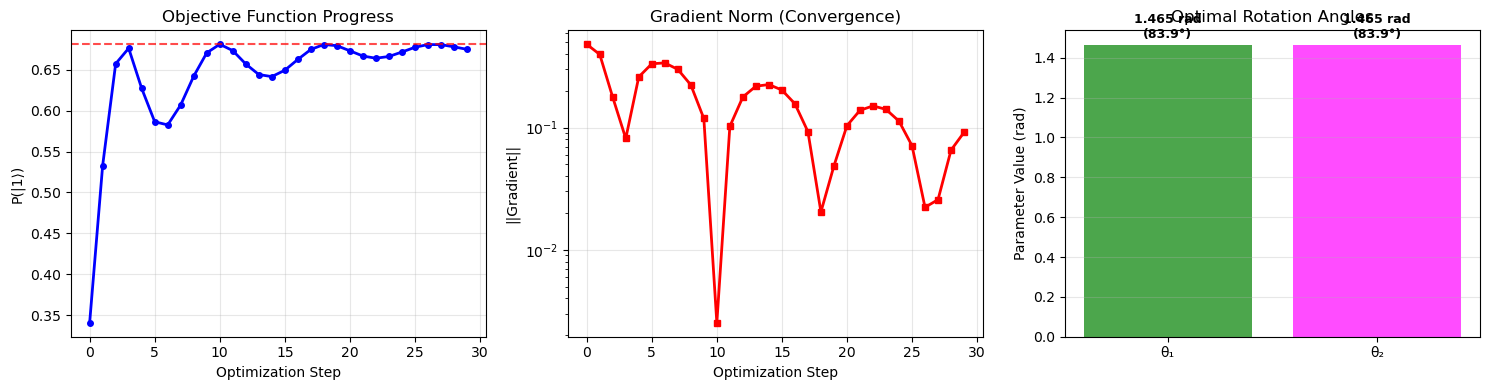


📊 OPTIMIZATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 Maximum probability: P(|1⟩) = 0.681174
🔄 Optimization steps: 30
📈 Final gradient norm: 9.15e-02
✅ JAX gradients enabled end-to-end quantum optimization!


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Create simple visualization of optimization results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

steps = np.arange(len(objective_history))

# Plot 1: Optimization progress
axes[0].plot(steps, objective_history, 'b-o', linewidth=2, markersize=4)
axes[0].set_xlabel('Optimization Step')
axes[0].set_ylabel('P(|1⟩)')
axes[0].set_title('Objective Function Progress')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=max(objective_history), color='r', linestyle='--', alpha=0.7)

# Plot 2: Gradient norm (convergence indicator)
axes[1].semilogy(steps, gradient_history, 'r-s', linewidth=2, markersize=4)
axes[1].set_xlabel('Optimization Step')
axes[1].set_ylabel('||Gradient||')
axes[1].set_title('Gradient Norm (Convergence)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Final optimized parameters
theta1_final = float(params[0])
theta2_final = float(params[1])
param_names = ['θ₁', 'θ₂']
param_values = [theta1_final, theta2_final]
param_degrees = [theta1_final*180/np.pi, theta2_final*180/np.pi]

bars = axes[2].bar(param_names, param_values, color=['green', 'magenta'], alpha=0.7)
axes[2].set_ylabel('Parameter Value (rad)')
axes[2].set_title('Optimal Rotation Angles')
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, rad_val, deg_val) in enumerate(zip(bars, param_values, param_degrees)):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{rad_val:.3f} rad\n({deg_val:.1f}°)',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
max_prob = np.max(objective_history)
print(f"\n📊 OPTIMIZATION SUMMARY")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"🎯 Maximum probability: P(|1⟩) = {max_prob:.6f}")
print(f"🔄 Optimization steps: {len(objective_history)}")
print(f"📈 Final gradient norm: {gradient_history[-1]:.2e}")
print(f"✅ JAX gradients enabled end-to-end quantum optimization!")